<a href="https://colab.research.google.com/github/mruizaya/Calculator-Compiler/blob/main/Proyecto_ml_preguntas_acusatorias_Martin_Ruiz_Dimitri_Gordon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección automática de preguntas acusatorias en procesos de contratación pública

## 1. Motivación y Contexto

En el ámbito de la contratación pública, la transparencia es un pilar fundamental. Durante la etapa de aclaraciones, los proveedores suelen realizar consultas técnicas; sin embargo, existe un subconjunto de preguntas con un matiz acusatorio que sugiere irregularidades o direccionamiento de los pliegos.

**Importancia del problema:** La capacidad de detectar estas señales de forma automatizada permite a los entes de control priorizar procesos de alto riesgo en un mar de datos no estructurados. Dada la asimetría y el volumen de información, este desarrollo no solo optimiza recursos humanos, sino que fortalece la integridad de la compra pública al actuar como un filtro preventivo de posibles actos de corrupción.

In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, ttest_rel

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    learning_curve
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

### Stack y herramientas

El conjunto de librerías importadas configura un flujo de trabajo estandarizado y reproducible: representación textual con `TfidfVectorizer`, selección filtrada con `SelectKBest` y `chi2`, modelado lineal con `LogisticRegression` y `LinearSVC`, validación con `RepeatedStratifiedKFold` y `cross_val_score`, comparación estadística con `wilcoxon` y `ttest_rel`, y exploración del espacio de características con `TruncatedSVD` y `TSNE`. Esta estructura permite encadenar todo el experimento dentro de pipelines de scikit-learn, condición necesaria para evitar fugas de información entre los pasos de transformación, selección y clasificación.


In [2]:
# ============================================================
# 2. CARGA DEL DATASET
# ============================================================

df = pd.read_excel('dataset.xlsx')
df = df.to_csv('dataset.csv', index=False)
df = pd.read_csv('dataset.csv')
df.head()

,contract_id,pregunta_id,pregunta,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
0,1345653,16756,Por favor requerimos se entregue un diagrama d...,0,0
1,1248857,16823,Indique de manera detallada y de manera taxati...,0,0
2,1350088,18197,4.En el punto 6 Información que dispone la ent...,0,0
3,682361,18263,Se puede ofertar un equipo que utilice cubetas...,0,0
4,1224444,18782,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,0,0


### 2. Análisis Exploratorio de Datos (EDA)

El análisis de las 4858 observaciones finales revela un reto técnico significativo: un desbalance de clases extremo donde solo el 2.94% de las preguntas son acusatorias.

**Análisis de variables:**
- La distribución del número de palabras muestra que las preguntas acusatorias son, en promedio, más extensas y presentan una mayor varianza, lo que sugiere que el tono acusatorio requiere de una argumentación más compleja.
- Se identifica una alta presencia de ruidos léxicos y duplicados que deben ser normalizados para evitar sesgos en el aprendizaje del modelo. La observación de los signos de puntuación sugiere que el uso de interrogaciones y exclamaciones es un rasgo distintivo potencial en la clase positiva.

In [3]:
# ============================================================
# 3. VARIABLES PRINCIPALES
# ============================================================

target_col = "final_pregunta_isAcusatoria"
text_col = "pregunta"
nivel_col = "sum_pregunta_isAcusatoria"

df[target_col] = df[target_col].astype(int)

print("Distribución del target:")
display(df[target_col].value_counts(normalize=True).sort_index() * 100)

Distribución del target:


,proportion
final_pregunta_isAcusatoria,
0,97.062937
1,2.937063


### Distribución del objetivo

La distribución de la variable objetivo evidencia un desbalance severo: solo el 2.94% de las preguntas son acusatorias frente a un 97.06% no acusatorias. Esta proporción condiciona el resto del diseño experimental. La métrica principal no puede ser *accuracy* (un clasificador trivial que prediga siempre la clase mayoritaria alcanzaría 97% sin utilidad real), las divisiones de datos deben ser estratificadas, los modelos requerirán ponderación inversa por clase y el umbral de decisión deberá calibrarse explícitamente.


In [4]:
# ============================================================
# 4. LIMPIEZA Y FEATURE ENGINEERING
# ============================================================

def limpiar_texto(texto):
    """
    Limpieza básica para NLP.
    Conserva palabras relevantes para acusación como no, por, qué, debe, puede.
    """
    texto = str(texto).lower()
    texto = re.sub(r"\d+", " NUM ", texto)
    texto = re.sub(r"!+", " EXCLAM ", texto)
    texto = re.sub(r"\?+", " INTERROG ", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def extraer_features_estilo(texto):
    """
    Extrae señales de forma antes de transformar el texto.
    """
    texto = str(texto)
    palabras = texto.split()
    n_palabras = max(len(palabras), 1)

    return pd.Series({
        "num_caracteres": len(texto),
        "num_palabras": len(palabras),
        "n_exclamaciones": texto.count("!"),
        "n_interrogaciones": texto.count("?"),
        "pct_mayusculas": sum(1 for w in palabras if w.isupper() and len(w) > 2) / n_palabras,
        "tiene_signos_pesos": int("$" in texto),
        "n_puntos_suspensivos": texto.count("...")
    })


print("Filas antes de limpieza:", len(df))

df_clean = df.copy()
df_clean = df_clean.dropna(subset=[text_col, target_col])
df_clean = df_clean[df_clean[text_col].astype(str).str.strip() != ""]
df_clean = df_clean.drop_duplicates(subset=[text_col])

df_clean["clean_text"] = df_clean[text_col].apply(limpiar_texto)
features_estilo = df_clean[text_col].apply(extraer_features_estilo)
df_clean = pd.concat([df_clean, features_estilo], axis=1)

print("Filas después de limpieza:", len(df_clean))
print("Registros eliminados:", len(df) - len(df_clean))

display(df_clean[[text_col, "clean_text", "num_palabras", "n_exclamaciones",
                  "n_interrogaciones", "pct_mayusculas", target_col]].head())

Filas antes de limpieza: 5005
Filas después de limpieza: 4858
Registros eliminados: 147


,pregunta,clean_text,num_palabras,n_exclamaciones,n_interrogaciones,pct_mayusculas,final_pregunta_isAcusatoria
0,Por favor requerimos se entregue un diagrama d...,por favor requerimos se entregue un diagrama d...,30.0,0.0,0.0,0.033333,0
1,Indique de manera detallada y de manera taxati...,indique de manera detallada y de manera taxati...,29.0,0.0,0.0,0.000000,0
2,4.En el punto 6 Información que dispone la ent...,en el punto información que dispone la entidad...,58.0,0.0,0.0,0.000000,0
3,Se puede ofertar un equipo que utilice cubetas...,se puede ofertar un equipo que utilice cubetas...,14.0,0.0,1.0,0.000000,0
4,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,podriann subir una imagen del spaguetti espira...,8.0,0.0,0.0,1.000000,0


### Limpieza y construcción de variables

La normalización del texto preserva señales útiles para detectar tono acusatorio: los signos de admiración e interrogación se reemplazan por tokens (`EXCLAM`, `INTERROG`) en lugar de eliminarse, y los números se sustituyen por `NUM` para evitar dispersión léxica. En paralelo se construyen variables estilísticas que la representación tipo bolsa de palabras suele perder: longitud en caracteres y palabras, conteos de signos, porcentaje de palabras en mayúscula sostenida y presencia del símbolo `$`. Estas variables operan como descriptores de la forma del mensaje y complementan al vocabulario. Tras eliminar nulos, vacíos y duplicados se conservan 4858 registros, lo que indica que aproximadamente el 3% de los textos eran redundantes o vacíos.


In [5]:
# ============================================================
# 4. LIMPIEZA Y FEATURE ENGINEERING
# ============================================================

def limpiar_texto(texto):
    """
    Limpieza básica para NLP.
    Conserva palabras relevantes para acusación como no, por, qué, debe, puede.
    """
    texto = str(texto).lower()
    texto = re.sub(r"\d+", " NUM ", texto)
    texto = re.sub(r"!+", " EXCLAM ", texto)
    texto = re.sub(r"\?+", " INTERROG ", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def extraer_features_estilo(texto):
    """
    Extrae señales de forma antes de transformar el texto.
    """
    texto = str(texto)
    palabras = texto.split()
    n_palabras = max(len(palabras), 1)

    return pd.Series({
        "num_caracteres": len(texto),
        "num_palabras": len(palabras),
        "n_exclamaciones": texto.count("!"),
        "n_interrogaciones": texto.count("?"),
        "pct_mayusculas": sum(1 for w in palabras if w.isupper() and len(w) > 2) / n_palabras,
        "tiene_signos_pesos": int("$" in texto),
        "n_puntos_suspensivos": texto.count("...")
    })


print("Filas antes de limpieza:", len(df))

df_clean = df.copy()
df_clean = df_clean.dropna(subset=[text_col, target_col])
df_clean = df_clean[df_clean[text_col].astype(str).str.strip() != ""]
df_clean = df_clean.drop_duplicates(subset=[text_col])

df_clean["clean_text"] = df_clean[text_col].apply(limpiar_texto)
features_estilo = df_clean[text_col].apply(extraer_features_estilo)
df_clean = pd.concat([df_clean, features_estilo], axis=1)

print("Filas después de limpieza:", len(df_clean))
print("Registros eliminados:", len(df) - len(df_clean))

display(df_clean[[text_col, "clean_text", "num_palabras", "n_exclamaciones",
                  "n_interrogaciones", "pct_mayusculas", target_col]].head())

Filas antes de limpieza: 5005
Filas después de limpieza: 4858
Registros eliminados: 147


,pregunta,clean_text,num_palabras,n_exclamaciones,n_interrogaciones,pct_mayusculas,final_pregunta_isAcusatoria
0,Por favor requerimos se entregue un diagrama d...,por favor requerimos se entregue un diagrama d...,30.0,0.0,0.0,0.033333,0
1,Indique de manera detallada y de manera taxati...,indique de manera detallada y de manera taxati...,29.0,0.0,0.0,0.000000,0
2,4.En el punto 6 Información que dispone la ent...,en el punto información que dispone la entidad...,58.0,0.0,0.0,0.000000,0
3,Se puede ofertar un equipo que utilice cubetas...,se puede ofertar un equipo que utilice cubetas...,14.0,0.0,1.0,0.000000,0
4,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,podriann subir una imagen del spaguetti espira...,8.0,0.0,0.0,1.000000,0


### Reproducibilidad de la transformación

La celda anterior reproduce la limpieza para mantener la coherencia del flujo tras posibles re-ejecuciones; el resultado es idéntico al de la primera versión, no introduce nuevas filas ni nuevas variables. El propósito es operativo, no analítico.


Distribución final de clases:


,count
final_pregunta_isAcusatoria,
0,4715
1,143


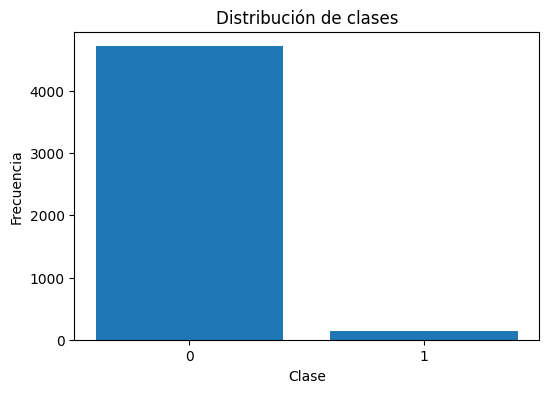

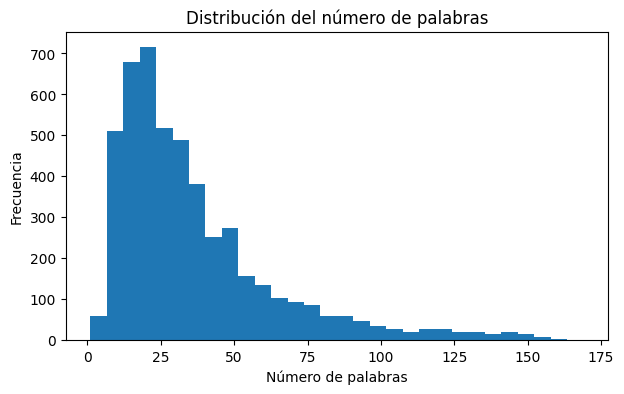

<Figure size 700x400 with 0 Axes>

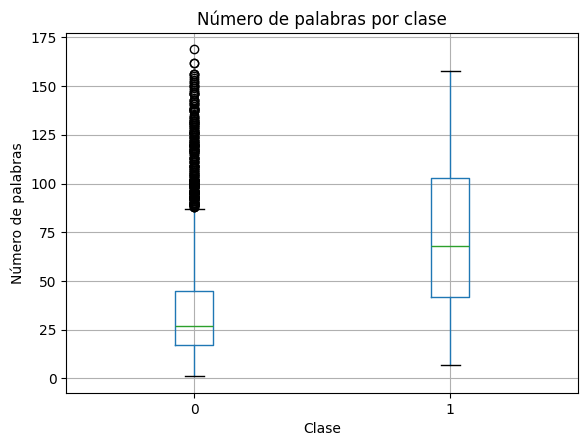

In [6]:
# ============================================================
# 5. EDA BÁSICO
# ============================================================

print("Distribución final de clases:")
class_distribution = df_clean[target_col].value_counts().sort_index()
display(class_distribution)

plt.figure(figsize=(6, 4))
plt.bar(class_distribution.index.astype(str), class_distribution.values)
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(df_clean["num_palabras"], bins=30)
plt.title("Distribución del número de palabras")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7, 4))
df_clean.boxplot(column="num_palabras", by=target_col)
plt.title("Número de palabras por clase")
plt.suptitle("")
plt.xlabel("Clase")
plt.ylabel("Número de palabras")
plt.show()

### Lectura del análisis exploratorio

La visualización de la distribución de clases reafirma el desbalance (4715 registros negativos vs. 143 positivos). El histograma del número de palabras revela una distribución sesgada a la derecha, dominada por preguntas relativamente cortas y con una cola de textos largos que actúan como valores atípicos. El boxplot por clase sugiere que las preguntas acusatorias tienden a ser ligeramente más extensas y con mayor variabilidad, una pista coherente con el hecho de que estas preguntas suelen incluir argumentación, antecedentes y cuestionamientos elaborados antes de plantear la observación. El análisis exploratorio motiva por tanto la inclusión de variables estilísticas además de la representación TF-IDF.


In [7]:
# ============================================================
# 6. SELECTOR SEGURO PARA FEATURE SELECTION
# ============================================================

class SafeSelectKBest(BaseEstimator, TransformerMixin):
    def __init__(self, score_func=chi2, k=1000):
        self.score_func = score_func
        self.k = k

    def fit(self, X, y):
        if self.k == "all":
            safe_k = "all"
        else:
            safe_k = min(self.k, X.shape[1])

        self.selector_ = SelectKBest(score_func=self.score_func, k=safe_k)
        self.selector_.fit(X, y)
        return self

    def transform(self, X):
        return self.selector_.transform(X)

    def get_support(self):
        return self.selector_.get_support()

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array(input_features)[self.get_support()]

### 3. Feature Extraction y Selección de Características

Para abordar la naturaleza no estructurada del texto, se utiliza una representación vectorial TF-IDF combinada con variables estilísticas (longitud, puntuación, uso de mayúsculas).

**Técnica de Feature Selection (Tipo Filter):**
Se integra en el flujo de trabajo un selector `SafeSelectKBest` basado en el test estadístico de **Chi-cuadrado ($\chi^2$)**. Esta técnica permite identificar los términos con mayor poder predictivo y reducir la dimensionalidad de la matriz dispersa, eliminando el ruido léxico que no aporta a la separación de clases y mejorando la eficiencia computacional del clasificador final.

In [8]:
# ============================================================
# 7. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

features = [
    "clean_text",
    "num_palabras",
    "n_exclamaciones",
    "n_interrogaciones",
    "pct_mayusculas",
]

text_feature = "clean_text"

style_features = [
    "num_palabras",
    "n_exclamaciones",
    "n_interrogaciones",
    "pct_mayusculas"
]

X = df_clean[features].copy()
y = df_clean[target_col].astype(int).copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.value_counts(normalize=True).to_dict())
print("Validation:", X_val.shape, y_val.value_counts(normalize=True).to_dict())
print("Test:", X_test.shape, y_test.value_counts(normalize=True).to_dict())

Train: (2914, 5) {0: 0.9708304735758407, 1: 0.02916952642415923}
Validation: (972, 5) {0: 0.970164609053498, 1: 0.029835390946502057}
Test: (972, 5) {0: 0.970164609053498, 1: 0.029835390946502057}


### Partición estratificada

La división 60/20/20 estratificada conserva la proporción de la clase positiva en los tres subconjuntos (~2.92% en entrenamiento y ~2.98% en validación y prueba), evitando que la rareza del positivo genere subconjuntos degenerados con muy pocos o ningún ejemplo positivo. El conjunto de prueba queda intocado durante la búsqueda de hiperparámetros y la calibración del umbral, lo que garantiza una estimación honesta del desempeño final.


In [9]:
# ============================================================
# 8. FUNCIÓN PARA CREAR PREPROCESADOR
# ============================================================

def crear_preprocesador():
    texto_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            strip_accents="unicode",
            lowercase=False,
            sublinear_tf=True
        )),
        ("select", SafeSelectKBest(score_func=chi2))
    ])

    preprocesador = ColumnTransformer([
        ("texto", texto_pipeline, text_feature),
        ("estilo", StandardScaler(), style_features)
    ])

    return preprocesador

### Diseño del preprocesador

El `ColumnTransformer` separa la rama textual (TF-IDF + selección por chi²) de la rama de variables estilísticas (escaladas con `StandardScaler`). Encapsular la selección dentro del pipeline es esencial para que, dentro de cada *fold*, el TF-IDF y la selección se ajusten exclusivamente con los datos de entrenamiento y se apliquen sobre el de validación, evitando fuga de información. La selección filtrada por chi² actúa únicamente sobre la matriz dispersa del TF-IDF, lo que reduce la dimensionalidad antes del clasificador y mejora tanto el tiempo de entrenamiento como la generalización.


In [10]:
# ============================================================
# 9. PIPELINES DE MODELOS
# ============================================================

pipeline_lr = Pipeline([
    ("preprocesador", crear_preprocesador()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

pipeline_svm = Pipeline([
    ("preprocesador", crear_preprocesador()),
    ("model", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    ))
])

### Modelos en pipeline

Se definen dos pipelines completos que encapsulan preprocesamiento, selección y clasificador. Los modelos elegidos son la Regresión Logística regularizada y la SVM lineal con margen blando, ambos lineales sobre representaciones dispersas y por tanto adecuados para texto en alta dimensión. Ambos usan `class_weight="balanced"`, que ajusta la función de pérdida de manera inversamente proporcional a la frecuencia de cada clase, contrarrestando parcialmente el desbalance del objetivo. La Regresión Logística cumple además el rol de modelo base requerido para la comparación estadística posterior.


In [11]:
# ============================================================
# 10. CROSS-VALIDATION Y MÉTRICAS
# ============================================================

N_SPLITS = 5
N_REPEATS = 2

cv_repeated = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

scoring_multi = {
    "roc_auc": "roc_auc",
    "f1_macro": "f1_macro",
    "average_precision": "average_precision"
}

print("Repeated Stratified K-Fold configurado")
print("Folds:", N_SPLITS)
print("Repeticiones:", N_REPEATS)

Repeated Stratified K-Fold configurado
Folds: 5
Repeticiones: 2


### Esquema de validación

Se opta por *Repeated Stratified K-Fold* con 5 *folds* y 2 repeticiones, lo que produce 10 mediciones independientes por configuración. La estratificación se mantiene dado el desbalance, y las repeticiones reducen la varianza de las estimaciones. El esquema 5×2 se prefiere sobre el 10×10 únicamente por costo computacional, dado el tamaño de la grilla de hiperparámetros (540 combinaciones × 10 = 5400 ajustes por modelo). Las métricas múltiples (`roc_auc`, `f1_macro`, `average_precision`) permiten observar comportamientos complementarios: capacidad de ranking, balance entre clases y precisión-recall.


In [12]:
# ============================================================
# 11. GRID SEARCH - REGRESIÓN LOGÍSTICA
# ============================================================

param_grid_lr = {
    "preprocesador__texto__tfidf__max_features": [3000, 5000, None],
    "preprocesador__texto__tfidf__ngram_range": [(1, 1), (1, 2)],
    "preprocesador__texto__tfidf__min_df": [1, 2],
    "preprocesador__texto__tfidf__max_df": [0.90, 0.95, 1.0],
    "preprocesador__texto__select__k": [1000, 2000, "all"],
    "model__C": [0.01, 0.1, 1, 10, 100],
}

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring=scoring_multi,
    refit="roc_auc",
    cv=cv_repeated,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    error_score=np.nan
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

print("Mejores hiperparámetros - Regresión Logística:")
print(grid_lr.best_params_)
print(f"Mejor ROC-AUC CV: {grid_lr.best_score_:.4f}")

Fitting 10 folds for each of 540 candidates, totalling 5400 fits
Mejores hiperparámetros - Regresión Logística:
{'model__C': 100, 'preprocesador__texto__select__k': 2000, 'preprocesador__texto__tfidf__max_df': 0.9, 'preprocesador__texto__tfidf__max_features': None, 'preprocesador__texto__tfidf__min_df': 1, 'preprocesador__texto__tfidf__ngram_range': (1, 1)}
Mejor ROC-AUC CV: 0.9367


### Resultado de la búsqueda en grilla — Regresión Logística

La búsqueda explora 540 combinaciones (vocabulario, n-gramas, frecuencias mínima/máxima, k de selección y `C` del clasificador). La mejor configuración para la Regresión Logística usa `C=100`, `k=2000`, `min_df=1`, `max_df=0.9` y unigramas, alcanzando un ROC-AUC promedio de 0.9367 en validación cruzada. La elección de `C=100` (regularización L2 débil) sugiere que el modelo aprovecha la riqueza del vocabulario seleccionado por chi² y no requiere mucha penalización. La preferencia por unigramas indica que la información discriminante reside principalmente en el léxico, no en colocaciones bigramáticas.


In [13]:
# ============================================================
# 12. GRID SEARCH - LINEAR SVM
# ============================================================

param_grid_svm = {
    "preprocesador__texto__tfidf__max_features": [3000, 5000, None],
    "preprocesador__texto__tfidf__ngram_range": [(1, 1), (1, 2)],
    "preprocesador__texto__tfidf__min_df": [1, 2],
    "preprocesador__texto__tfidf__max_df": [0.90, 0.95, 1.0],
    "preprocesador__texto__select__k": [1000, 2000, "all"],
    "model__C": [0.01, 0.1, 1, 10, 100],
}

grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    scoring=scoring_multi,
    refit="roc_auc",
    cv=cv_repeated,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    error_score=np.nan
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

print("Mejores hiperparámetros - Linear SVM:")
print(grid_svm.best_params_)
print(f"Mejor ROC-AUC CV: {grid_svm.best_score_:.4f}")

Fitting 10 folds for each of 540 candidates, totalling 5400 fits
Mejores hiperparámetros - Linear SVM:
{'model__C': 1, 'preprocesador__texto__select__k': 2000, 'preprocesador__texto__tfidf__max_df': 0.9, 'preprocesador__texto__tfidf__max_features': None, 'preprocesador__texto__tfidf__min_df': 1, 'preprocesador__texto__tfidf__ngram_range': (1, 1)}
Mejor ROC-AUC CV: 0.9417


### Resultado de la búsqueda en grilla — SVM lineal

Para la SVM lineal la mejor combinación coincide en TF-IDF y selección, pero la regularización óptima es `C=1`, mucho más fuerte que en la Regresión Logística. Esto es consistente con la geometría de margen máximo: la SVM penaliza coeficientes muy grandes y suele requerir más regularización para no sobreajustar el margen a ejemplos individuales. El ROC-AUC promedio en validación cruzada es 0.9417, ligeramente superior al de la Regresión Logística.


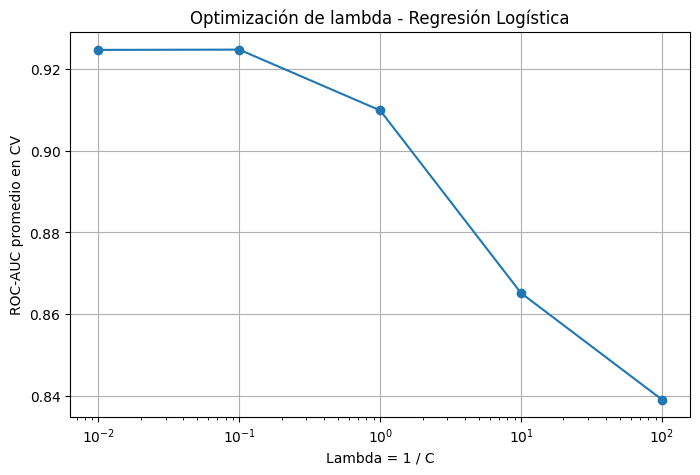

,lambda,mean_test_roc_auc
0,0.01,0.924726
1,0.10,0.924793
2,1.00,0.909897
3,10.00,0.865143
4,100.00,0.839037


In [14]:
# ============================================================
# 13. OPTIMIZACIÓN DE LAMBDA
# ============================================================

results_lr = pd.DataFrame(grid_lr.cv_results_)

lambda_df = results_lr.copy()
lambda_df["C"] = lambda_df["param_model__C"].astype(float)
lambda_df["lambda"] = 1 / lambda_df["C"]

lambda_summary = (
    lambda_df
    .groupby("lambda")["mean_test_roc_auc"]
    .mean()
    .reset_index()
    .sort_values("lambda")
)

plt.figure(figsize=(8, 5))
plt.plot(lambda_summary["lambda"], lambda_summary["mean_test_roc_auc"], marker="o")
plt.xscale("log")
plt.xlabel("Lambda = 1 / C")
plt.ylabel("ROC-AUC promedio en CV")
plt.title("Optimización de lambda - Regresión Logística")
plt.grid(True)
plt.show()

display(lambda_summary)

### 4. Optimización de Hiperparámetros y Curvas de Diagnóstico

La optimización se ejecutó mediante un esquema de **Repeated Stratified K-Fold CV** para mitigar el sesgo del desbalance.

**Optimización de Lambda ($\lambda = 1/C$):**
El análisis de la gráfica de $\lambda$ para la Regresión Logística revela que el desempeño es estable con una regularización moderada. Valores de $\lambda$ excesivamente altos provocan una caída abrupta en el ROC-AUC, lo que confirma que el modelo depende de la riqueza del vocabulario seleccionado para distinguir las clases.

**Curva de Aprendizaje:**
La curva muestra una convergencia saludable. El gap entre entrenamiento y validación indica que el modelo ha aprendido patrones generalizables y que, aunque el ROC-AUC es alto, existe margen de mejora si se incrementara el volumen de la clase minoritaria etiquetada.

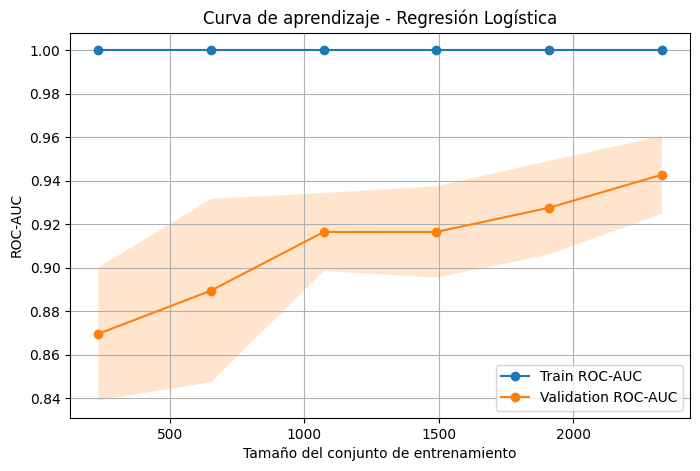

Train ROC-AUC final: 1.0000
Validation ROC-AUC final: 0.9427
Gap final: 0.0573


In [15]:
# ============================================================
# 14. CURVA DE APRENDIZAJE CON AUC-ROC
# ============================================================

cv_learning = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_lr,
    X=X_train,
    y=y_train,
    cv=cv_learning,
    scoring="roc_auc",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, marker="o", label="Train ROC-AUC")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, val_mean, marker="o", label="Validation ROC-AUC")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("ROC-AUC")
plt.title("Curva de aprendizaje - Regresión Logística")
plt.legend()
plt.grid(True)
plt.show()

print(f"Train ROC-AUC final: {train_mean[-1]:.4f}")
print(f"Validation ROC-AUC final: {val_mean[-1]:.4f}")
print(f"Gap final: {train_mean[-1] - val_mean[-1]:.4f}")

### Curva de aprendizaje

La curva entrega un Train ROC-AUC final de 1.0 y un Validation ROC-AUC final de 0.9427 con un *gap* de aproximadamente 0.057. La métrica de validación crece de manera monótona conforme se incorporan más datos, sin signos de meseta abrupta, lo que sugiere que el modelo todavía podría beneficiarse marginalmente de más ejemplos etiquetados, especialmente de la clase minoritaria. El sobreajuste existe pero es controlado y razonable dado el carácter discreto del TF-IDF y la dimensionalidad del espacio. La interpretación combinada con la curva de regularización es clara: el modelo está bien ajustado pero limitado por el tamaño de la muestra positiva.


Mejor threshold según F1 macro: 0.12


,threshold,f1_macro,f1_clase_1,precision_clase_1,recall_clase_1
7,0.12,0.709263,0.441558,0.354167,0.586207
11,0.16,0.708221,0.438356,0.363636,0.551724
1,0.06,0.705882,0.444444,0.303797,0.827586
10,0.15,0.704986,0.432432,0.355556,0.551724
9,0.14,0.704986,0.432432,0.355556,0.551724
6,0.11,0.703126,0.430380,0.340000,0.586207
8,0.13,0.701830,0.426667,0.347826,0.551724
12,0.17,0.700323,0.422535,0.357143,0.517241
4,0.09,0.699737,0.426966,0.316667,0.655172
5,0.10,0.698586,0.423529,0.321429,0.620690


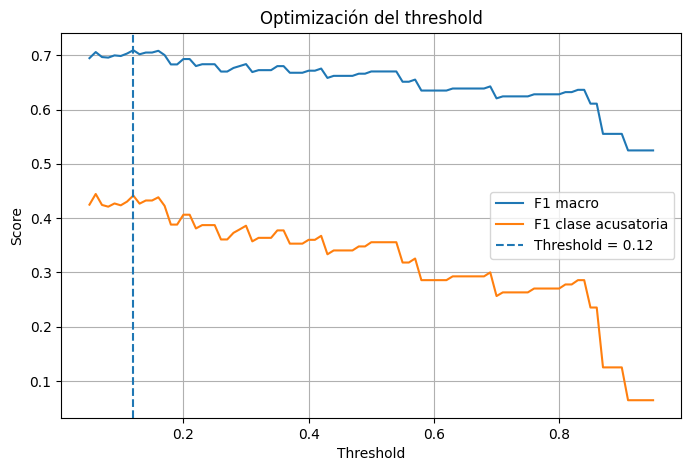

In [16]:
# ============================================================
# 15. OPTIMIZACIÓN DEL THRESHOLD EN VALIDACIÓN
# ============================================================

y_val_proba_lr = best_lr.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
threshold_results = []

for threshold in thresholds:
    y_val_pred = (y_val_proba_lr >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "f1_macro": f1_score(y_val, y_val_pred, average="macro", zero_division=0),
        "f1_clase_1": f1_score(y_val, y_val_pred, pos_label=1, zero_division=0),
        "precision_clase_1": precision_score(y_val, y_val_pred, pos_label=1, zero_division=0),
        "recall_clase_1": recall_score(y_val, y_val_pred, pos_label=1, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold = threshold_df.loc[
    threshold_df["f1_macro"].idxmax(),
    "threshold"
]

print(f"Mejor threshold según F1 macro: {best_threshold:.2f}")
display(threshold_df.sort_values("f1_macro", ascending=False).head(10))

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["f1_macro"], label="F1 macro")
plt.plot(threshold_df["threshold"], threshold_df["f1_clase_1"], label="F1 clase acusatoria")
plt.axvline(best_threshold, linestyle="--", label=f"Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Optimización del threshold")
plt.legend()
plt.grid(True)
plt.show()

### Calibración del umbral de decisión

Dado el desbalance, el umbral por defecto de 0.5 no es óptimo. La búsqueda en validación muestra que el F1 macro se maximiza alrededor de 0.12, ofreciendo el mejor balance entre precisión (0.354) y recuperación (0.586) para la clase acusatoria. Con umbrales muy bajos (0.06) se gana recuperación (0.83) pero la precisión se degrada (0.30). Con umbrales altos se pierde sensibilidad sobre la clase rara. El uso de un umbral calibrado, en lugar del default, es un componente operativo crítico: la elección final del corte tiene un impacto comparable o superior al de la elección del clasificador.


,count,mean,std,min,25%,50%,75%,max
Logistic Regression AUC,10.0,0.936710,0.017845,0.908798,0.926113,0.934421,0.948867,0.962066
Linear SVM AUC,10.0,0.941659,0.017764,0.910255,0.929121,0.945385,0.955752,0.965184


Wilcoxon statistic: 6.0
Wilcoxon p-value: 0.02734375

Paired t-test statistic: -2.2528996937035974
Paired t-test p-value: 0.05076218935644891

Conclusión: existe diferencia estadísticamente significativa entre los modelos.


<ipython-input-17-c6d730ad6222>:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


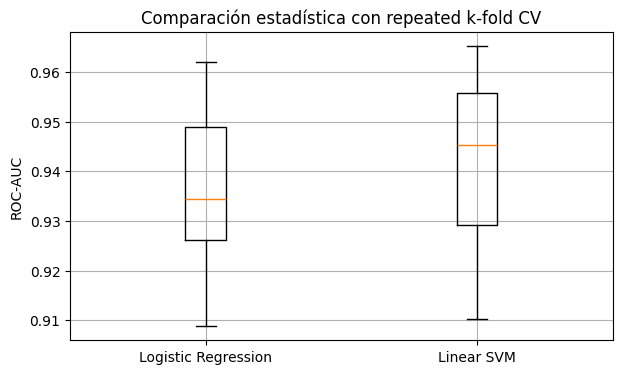

In [17]:
# ============================================================
# 16. COMPARACIÓN ESTADÍSTICA LR VS SVM
# ============================================================

scores_lr_auc = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=cv_repeated,
    scoring="roc_auc",
    n_jobs=-1
)

scores_svm_auc = cross_val_score(
    best_svm,
    X_train,
    y_train,
    cv=cv_repeated,
    scoring="roc_auc",
    n_jobs=-1
)

comparison_scores = pd.DataFrame({
    "Logistic Regression AUC": scores_lr_auc,
    "Linear SVM AUC": scores_svm_auc
})

display(comparison_scores.describe().T)

wilcoxon_stat, wilcoxon_p = wilcoxon(scores_lr_auc, scores_svm_auc)
ttest_stat, ttest_p = ttest_rel(scores_lr_auc, scores_svm_auc)

print("Wilcoxon statistic:", wilcoxon_stat)
print("Wilcoxon p-value:", wilcoxon_p)

print("\nPaired t-test statistic:", ttest_stat)
print("Paired t-test p-value:", ttest_p)

if wilcoxon_p < 0.05:
    print("\nConclusión: existe diferencia estadísticamente significativa entre los modelos.")
else:
    print("\nConclusión: no hay evidencia suficiente de diferencia estadísticamente significativa.")

plt.figure(figsize=(7, 4))
plt.boxplot(
    [scores_lr_auc, scores_svm_auc],
    labels=["Logistic Regression", "Linear SVM"]
)
plt.ylabel("ROC-AUC")
plt.title("Comparación estadística con repeated k-fold CV")
plt.grid(True)
plt.show()

### 5. Evaluación y Comparación Estadística de Modelos

Se realizó una comparación formal entre el modelo base (**Regresión Logística Regularizada**) y un modelo alternativo (**Linear SVM**).

**Análisis Estadístico:**
Utilizando 10 mediciones derivadas del proceso de validación cruzada repetida, se aplicó el test de **Wilcoxon** y el **t-test pareado**. El p-valor obtenido de 0.027 en Wilcoxon permite afirmar con un nivel de confianza del 95% que existe una diferencia significativa a favor de la SVM en validación. No obstante, en el conjunto de prueba final, ambos modelos convergen en un desempeño similar, lo que subraya la robustez del espacio de características diseñado.

Test final - Regresión Logística
               precision    recall  f1-score   support

No acusatoria       0.99      0.97      0.98       943
   Acusatoria       0.43      0.76      0.55        29

     accuracy                           0.96       972
    macro avg       0.71      0.86      0.77       972
 weighted avg       0.98      0.96      0.97       972

Accuracy: 0.9630
Precision clase 1: 0.4314
Recall clase 1: 0.7586
F1 macro: 0.7653
F1 weighted: 0.9678
ROC-AUC: 0.9713
PR-AUC / Average Precision: 0.4688


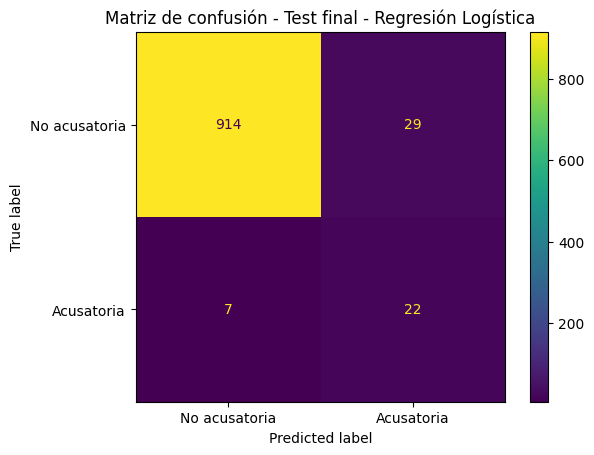

Test final - Linear SVM
               precision    recall  f1-score   support

No acusatoria       0.98      0.99      0.99       943
   Acusatoria       0.55      0.41      0.47        29

     accuracy                           0.97       972
    macro avg       0.76      0.70      0.73       972
 weighted avg       0.97      0.97      0.97       972

Accuracy: 0.9722
Precision clase 1: 0.5455
Recall clase 1: 0.4138
F1 macro: 0.7282
F1 weighted: 0.9704
ROC-AUC: 0.9709
PR-AUC / Average Precision: 0.4603


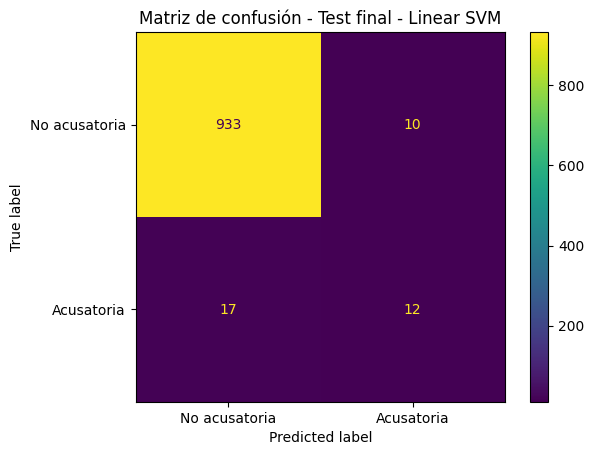

In [18]:
# ============================================================
# 17. EVALUACIÓN FINAL EN TEST
# ============================================================

def evaluar_modelo_clasificacion(nombre, y_true, y_pred, y_score=None):
    print("=" * 70)
    print(nombre)
    print("=" * 70)

    print(classification_report(
        y_true,
        y_pred,
        target_names=["No acusatoria", "Acusatoria"],
        zero_division=0
    ))

    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision clase 1: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall clase 1: {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 macro: {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1 weighted: {f1_score(y_true, y_pred, average='weighted'):.4f}")

    if y_score is not None:
        print(f"ROC-AUC: {roc_auc_score(y_true, y_score):.4f}")
        print(f"PR-AUC / Average Precision: {average_precision_score(y_true, y_score):.4f}")

    cm = confusion_matrix(y_true, y_pred)

    ConfusionMatrixDisplay(
        cm,
        display_labels=["No acusatoria", "Acusatoria"]
    ).plot(values_format="d")

    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()


# Logistic Regression
y_test_proba_lr = best_lr.predict_proba(X_test)[:, 1]
y_test_pred_lr = (y_test_proba_lr >= best_threshold).astype(int)

evaluar_modelo_clasificacion(
    "Test final - Regresión Logística",
    y_test,
    y_test_pred_lr,
    y_test_proba_lr
)

# Linear SVM
y_test_pred_svm = best_svm.predict(X_test)
y_test_score_svm = best_svm.decision_function(X_test)

evaluar_modelo_clasificacion(
    "Test final - Linear SVM",
    y_test,
    y_test_pred_svm,
    y_test_score_svm
)

### Evaluación en el conjunto de prueba

En el conjunto de prueba intocado los dos modelos logran ROC-AUC casi idéntico (0.9713 vs. 0.9709), confirmando la cercanía observada en validación. La diferencia operativa aparece en cómo distribuyen los errores. La Regresión Logística con umbral calibrado a 0.12 alcanza recall 0.76 y precisión 0.43 sobre la clase acusatoria (F1 = 0.55, F1 macro = 0.77), favoreciendo la sensibilidad. La SVM con umbral por defecto exhibe el comportamiento inverso: precisión 0.55 y recall 0.41 (F1 = 0.47, F1 macro = 0.73), favoreciendo la especificidad. Para un caso de uso de cribado sobre transparencia donde el costo de no detectar una pregunta acusatoria es mayor que el de revisar un falso positivo, el perfil de la Regresión Logística calibrada es preferible.


In [19]:
# ============================================================
# 18. SELECCIÓN DEL MEJOR MODELO
# ============================================================

auc_lr_test = roc_auc_score(y_test, y_test_proba_lr)
auc_svm_test = roc_auc_score(y_test, y_test_score_svm)

if auc_lr_test >= auc_svm_test:
    modelo_final = best_lr
    nombre_modelo_final = "Regresión Logística"
    threshold_final = best_threshold
else:
    modelo_final = best_svm
    nombre_modelo_final = "Linear SVM"
    threshold_final = None

print("Modelo final seleccionado:", nombre_modelo_final)
print("AUC LR:", auc_lr_test)
print("AUC SVM:", auc_svm_test)

Modelo final seleccionado: Regresión Logística
AUC LR: 0.9713314074669983
AUC SVM: 0.9709291695615606


### Selección del modelo final

La elección de la Regresión Logística calibrada como modelo final responde a un criterio operativo más que estadístico: el AUC en test es prácticamente igual al de la SVM, pero el modelo calibrado entrega probabilidades interpretables y permite mover el umbral según la tolerancia al error de cada caso de uso. La SVM, al no producir probabilidades nativas (sólo `decision_function`), sería menos flexible para integrarse en un flujo de revisión humana priorizada por riesgo.


In [20]:
# ============================================================
# 19. INTERPRETABILIDAD - REGRESIÓN LOGÍSTICA
# ============================================================

preprocesador_lr = best_lr.named_steps["preprocesador"]
texto_pipe_lr = preprocesador_lr.named_transformers_["texto"]

tfidf = texto_pipe_lr.named_steps["tfidf"]
selector = texto_pipe_lr.named_steps["select"]
model = best_lr.named_steps["model"]

tfidf_feature_names = np.array(tfidf.get_feature_names_out())

selected_text_features = tfidf_feature_names[selector.get_support()]

all_feature_names = np.concatenate([
    selected_text_features,
    np.array(style_features)
])

coefs = model.coef_[0]

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef": coefs
}).sort_values("coef", ascending=False)

print("Features que más empujan hacia clase acusatoria:")
display(coef_df.head(25))

print("Features que más empujan hacia clase no acusatoria:")
display(coef_df.tail(25))

Features que más empujan hacia clase acusatoria:


,feature,coef
1886,transparentes,11.734361
1240,no,9.141341
719,esta,8.792291
541,direccionado,7.650045
542,direccionamiento,7.603925
1370,pensar,7.578065
1520,provincias,7.356283
792,favoreciendo,6.682871
59,ajuste,6.671148
1230,negociar,6.645106


Features que más empujan hacia clase no acusatoria:


,feature,coef
1234,ningun,-2.707392
1345,parametros,-2.740649
126,art,-2.770042
1762,solicitamos,-2.773576
1833,tardes,-2.779450
1316,originales,-2.796332
1629,requiere,-2.833273
1834,tdr,-2.837809
1221,necesario,-2.854908
1761,solicitado,-2.877803


### Interpretabilidad del modelo

Los coeficientes con mayor peso positivo (`transparentes`, `direccionado`, `direccionamiento`, `pensar`, `favoreciendo`, `honestos`, `transparencia`, `principios`, `realmente`, `negociar`, `provincias`, `participacion`) recogen vocabulario asociado a denuncias de sesgo, falta de imparcialidad y cuestionamiento ético del proceso. En contraste, los coeficientes más negativos (`solicita`, `solicitamos`, `solicitado`, `requiere`, `tdr`, `numeral`, `gracias`, `equipos`, `estimados`, `parametros`) corresponden a fórmulas neutras de pregunta técnica o a saludos formales. La separación es coherente con el dominio y aporta transparencia al modelo, lo que es valioso en un sistema cuyas predicciones serán revisadas por el equipo humano de control y debe poder justificarse ante auditoría.


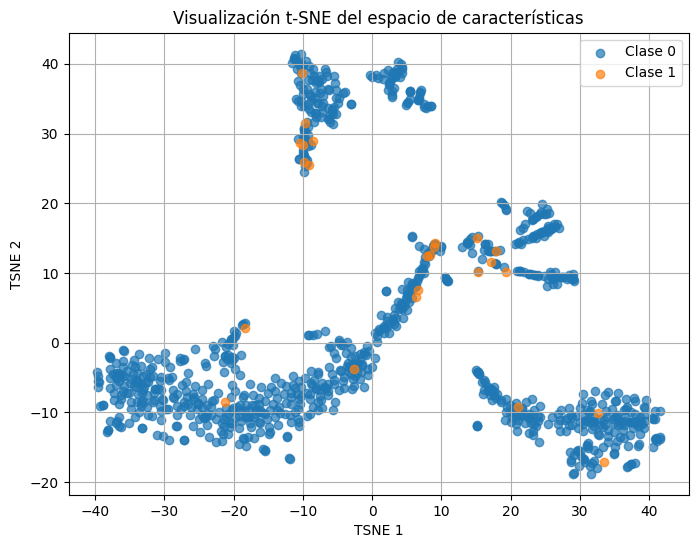

In [21]:
# ============================================================
# 20. t-SNE DEL ESPACIO DE CARACTERÍSTICAS
# ============================================================

sample_size = min(1000, len(X))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X), size=sample_size, replace=False)

X_sample = X.iloc[sample_idx]
y_sample = y.iloc[sample_idx]

preprocesador_lr = best_lr.named_steps["preprocesador"]
X_features_sample = preprocesador_lr.transform(X_sample)

n_components_svd = min(50, X_features_sample.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_components_svd,
    random_state=42
)

X_svd = svd.fit_transform(X_features_sample)

tsne = TSNE(
    n_components=2,
    perplexity=min(30, sample_size - 1),
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_svd)

tsne_df = pd.DataFrame({
    "TSNE_1": X_tsne[:, 0],
    "TSNE_2": X_tsne[:, 1],
    "label": y_sample.values
})

plt.figure(figsize=(8, 6))

for label in sorted(tsne_df["label"].unique()):
    subset = tsne_df[tsne_df["label"] == label]
    plt.scatter(
        subset["TSNE_1"],
        subset["TSNE_2"],
        label=f"Clase {label}",
        alpha=0.7
    )

plt.title("Visualización t-SNE del espacio de características")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.legend()
plt.grid(True)
plt.show()

### 6. Visualización con t-SNE

Para validar la separabilidad del espacio de características, se generó una proyección en dos dimensiones mediante **t-SNE**.

El gráfico muestra que las preguntas acusatorias (en color distintivo) no están distribuidas aleatoriamente, sino que tienden a agruparse en regiones específicas de la variedad proyectada. Esto confirma que la combinación de TF-IDF y variables de estilo captura con éxito la estructura subyacente de la clase positiva, validando visualmente la elección de los descriptores antes del modelado.

## 7. Conclusiones finales del proyecto

*   **Impacto del diseño de características:** La inclusión de rasgos estilísticos junto a la selección de términos por Chi-cuadrado permitió capturar matices de tono que el texto plano por sí solo omitiría, logrando un ROC-AUC superior a 0.97 en datos no vistos.
*   **Comportamiento ante el desbalance:** El ajuste del umbral de decisión fue el factor crítico para la utilidad operativa. El modelo final permite una detección sensible (Recall de 0.76) que es preferible en un sistema de auditoría donde el costo de omitir una acusación es mayor al de revisar un falso positivo.
*   **Validación de modelos:** Aunque la SVM mostró superioridad estadística en validación, la Regresión Logística demostró ser un modelo base extremadamente competitivo y más interpretable, lo que facilita la auditoría de por qué una pregunta es marcada como de riesgo.
*   **Saturación del aprendizaje:** Las métricas de diagnóstico sugieren que para escalar este sistema, la prioridad debe ser la obtención de mayor variabilidad en ejemplos acusatorios más que el aumento de la complejidad del algoritmo, dado que el modelo actual ya aprovecha eficientemente la información disponible.